## Imports

In [29]:
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [3]:
FEATURE_VARS = ["mag_avg_nt", "bx_gsm_nt", "by_gsm_nt", "bz_gsm_nt", "flow_speed_km_s", "proton_density_n_cc"]
TARGET_VAR = "kp_10"

In [5]:
df = pd.read_parquet("data/Processed/omni_minute.parquet")
df.head(10)

,year,day,hour,minute,mag_avg_nt,bx_gsm_nt,by_gsm_nt,bz_gsm_nt,flow_speed_km_s,proton_density_n_cc,day_cos,day_sin,hour_cos,hour_sin,minute_cos,minute_sin,kp_10
0,2000,1,0,0,6.82,-5.94,0.27,-0.08,NaN,NaN,0.999852,0.017213,1.0,0.0,1.000000,0.000000,53
1,2000,1,0,1,6.99,-5.88,1.95,1.08,664.7,3.12,0.999852,0.017213,1.0,0.0,0.994522,0.104528,53
2,2000,1,0,2,6.99,-5.71,2.74,2.24,663.2,3.24,0.999852,0.017213,1.0,0.0,0.978148,0.207912,53
3,2000,1,0,3,6.83,-5.33,3.18,2.78,662.2,3.11,0.999852,0.017213,1.0,0.0,0.951057,0.309017,53
4,2000,1,0,4,NaN,NaN,NaN,NaN,NaN,NaN,0.999852,0.017213,1.0,0.0,0.913545,0.406737,53
5,2000,1,0,5,6.98,-3.80,2.80,4.74,688.4,2.55,0.999852,0.017213,1.0,0.0,0.866025,0.500000,53
6,2000,1,0,6,NaN,NaN,NaN,NaN,688.4,2.55,0.999852,0.017213,1.0,0.0,0.809017,0.587785,53
7,2000,1,0,7,NaN,NaN,NaN,NaN,NaN,NaN,0.999852,0.017213,1.0,0.0,0.743145,0.669131,53
8,2000,1,0,8,NaN,NaN,NaN,NaN,NaN,NaN,0.999852,0.017213,1.0,0.0,0.669131,0.743145,53
9,2000,1,0,9,6.68,-3.54,2.82,4.77,NaN,NaN,0.999852,0.017213,1.0,0.0,0.587785,0.809017,53


In [7]:
df.describe()[FEATURE_VARS]

,mag_avg_nt,bx_gsm_nt,by_gsm_nt,bz_gsm_nt,flow_speed_km_s,proton_density_n_cc
count,1.294046e+07,1.294046e+07,1.294046e+07,1.294046e+07,1.089496e+07,1.089496e+07
mean,5.835097e+00,2.967980e-02,-4.511046e-02,-3.626282e-02,4.331765e+02,6.170464e+00
std,3.168381e+00,3.656561e+00,4.125610e+00,3.501261e+00,1.024982e+02,5.031114e+00
min,1.300000e-01,-4.951000e+01,-6.479000e+01,-5.557000e+01,2.305000e+02,3.000000e-02
25%,3.850000e+00,-2.630000e+00,-2.650000e+00,-1.890000e+00,3.559000e+02,3.120000e+00
50%,5.130000e+00,7.000000e-02,-1.100000e-01,-3.000000e-02,4.110000e+02,4.760000e+00
75%,6.960000e+00,2.680000e+00,2.580000e+00,1.820000e+00,4.895000e+02,7.500000e+00
max,7.291000e+01,3.995000e+01,6.990000e+01,6.970000e+01,1.089000e+03,8.095000e+01


## Examining NaN Distribution

In [9]:
nan_df = pd.DataFrame(columns=FEATURE_VARS)
for index, var in enumerate(FEATURE_VARS):
    nan_df[var] = df.groupby('year')[var].apply(lambda x: x.isna().sum())
fig = px.bar(nan_df, x=nan_df.index, y=FEATURE_VARS, title="NaN Yearly Composition")
fig.update_layout(yaxis_title="NaN Count")
fig.show()

In [11]:
def longest_nan_run(df, column):
    mask = df[column].isna()

    groups = (mask != mask.shift()).cumsum()

    runs = (
        mask.groupby(groups)
            .agg(["first", "size"])
    )

    missing_runs = runs[runs["first"]]

    longest_group = missing_runs["size"].idxmax()

    run_mask = groups == longest_group

    start_row = df.loc[run_mask].iloc[0]
    end_row = df.loc[run_mask].iloc[-1]

    return {
        "start": start_row,
        "end": end_row,
        "length_minutes": run_mask.sum()
    }

for feature in FEATURE_VARS:
    print(feature)
    result = longest_nan_run(df, feature)

    print("Start:")
    print(f"Year:   {result['start']['year']}")
    print(f"Day:    {result['start']['day']}")
    print(f"Hour:   {result['start']['hour']}")
    print(f"Minute: {result['start']['minute']}")
    print("\nEnd:")
    print(f"Year:   {result['end']['year']}")
    print(f"Day:    {result['end']['day']}")
    print(f"Hour:   {result['end']['hour']}")
    print(f"Minute: {result['end']['minute']}")
    print(f"\nLength: {result['length_minutes']} minutes")
    print("--------------------------------------------")

mag_avg_nt
Start:
Year:   2023.0
Day:    195.0
Hour:   6.0
Minute: 33.0

End:
Year:   2023.0
Day:    207.0
Hour:   15.0
Minute: 22.0

Length: 17810 minutes
--------------------------------------------
bx_gsm_nt
Start:
Year:   2023.0
Day:    195.0
Hour:   6.0
Minute: 33.0

End:
Year:   2023.0
Day:    207.0
Hour:   15.0
Minute: 22.0

Length: 17810 minutes
--------------------------------------------
by_gsm_nt
Start:
Year:   2023.0
Day:    195.0
Hour:   6.0
Minute: 33.0

End:
Year:   2023.0
Day:    207.0
Hour:   15.0
Minute: 22.0

Length: 17810 minutes
--------------------------------------------
bz_gsm_nt
Start:
Year:   2023.0
Day:    195.0
Hour:   6.0
Minute: 33.0

End:
Year:   2023.0
Day:    207.0
Hour:   15.0
Minute: 22.0

Length: 17810 minutes
--------------------------------------------
flow_speed_km_s
Start:
Year:   2023.0
Day:    195.0
Hour:   6.0
Minute: 32.0

End:
Year:   2023.0
Day:    207.0
Hour:   15.0
Minute: 27.0

Length: 17816 minutes
--------------------------------------

In [13]:
def long_nan_stats(series, threshold=30):
    runs = (
        series.isna()
              .astype(int)
              .groupby(series.notna().cumsum())
              .sum()
    )

    runs = runs[runs > 0]

    return {
        "num_runs": (runs > threshold).sum(),
        "total_minutes": runs[runs > threshold].sum(),
        "max_run": runs.max()
    }

THRESHOLD = 60
print(f"NaN consecutive runs with threshold > {THRESHOLD} minutes")
for feature in FEATURE_VARS:
    print(f"{feature}: {long_nan_stats(df[feature], THRESHOLD)}")

NaN consecutive runs with threshold > 60 minutes
mag_avg_nt: {'num_runs': 2409, 'total_minutes': 527008, 'max_run': 17810}
bx_gsm_nt: {'num_runs': 2409, 'total_minutes': 527008, 'max_run': 17810}
by_gsm_nt: {'num_runs': 2409, 'total_minutes': 527008, 'max_run': 17810}
bz_gsm_nt: {'num_runs': 2409, 'total_minutes': 527008, 'max_run': 17810}
flow_speed_km_s: {'num_runs': 2515, 'total_minutes': 542538, 'max_run': 17816}
proton_density_n_cc: {'num_runs': 2515, 'total_minutes': 542538, 'max_run': 17816}


## Handling NaN Data

In [15]:
def interpolate_remove_nans(df, limit=60):
    rows_before = len(df)

    for feature in FEATURE_VARS:
        df[feature] = df[feature].interpolate(
            method="linear",
            limit=limit,
            limit_direction="both"
        )

    df = df.dropna(subset=FEATURE_VARS + [TARGET_VAR])

    rows_after = len(df)

    print(f"Rows before: {rows_before:,}")
    print(f"Rows after:  {rows_after:,}")
    print(f"Rows removed: {rows_before - rows_after:,}")
    print(f"Percent removed: {(rows_before - rows_after) / rows_before:.2%}")
    return df


df = interpolate_remove_nans(df)

Rows before: 13,936,320
Rows after:  13,654,494
Rows removed: 281,826
Percent removed: 2.02%


In [17]:
df.isna().sum()

year                   0
day                    0
hour                   0
minute                 0
mag_avg_nt             0
bx_gsm_nt              0
by_gsm_nt              0
bz_gsm_nt              0
flow_speed_km_s        0
proton_density_n_cc    0
day_cos                0
day_sin                0
hour_cos               0
hour_sin               0
minute_cos             0
minute_sin             0
kp_10                  0
dtype: int64

In [19]:
df.to_parquet("data/Processed/omni_minute_cleaned.parquet")

In [21]:
## Do the same for train + test datasets
print("Train dataset")
train_df = pd.read_parquet("data/Processed/omni_train.parquet")
train_df = interpolate_remove_nans(train_df)
train_df.to_parquet("data/Processed/omni_train_cleaned.parquet")

print("Test dataset")
test_df = pd.read_parquet("data/Processed/omni_test.parquet")
test_df = interpolate_remove_nans(test_df)
test_df.to_parquet("data/Processed/omni_test_cleaned.parquet")

Train dataset
Rows before: 12,358,079
Rows after:  12,135,459
Rows removed: 222,620
Percent removed: 1.80%
Test dataset
Rows before: 1,578,241
Rows after:  1,519,035
Rows removed: 59,206
Percent removed: 3.75%


In [23]:
print(train_df.isna().sum())
print(test_df.isna().sum())

datetime               0
year                   0
day                    0
hour                   0
minute                 0
mag_avg_nt             0
bx_gsm_nt              0
by_gsm_nt              0
bz_gsm_nt              0
flow_speed_km_s        0
proton_density_n_cc    0
day_cos                0
day_sin                0
hour_cos               0
hour_sin               0
minute_cos             0
minute_sin             0
kp_10                  0
data_split             0
dtype: int64
datetime               0
year                   0
day                    0
hour                   0
minute                 0
mag_avg_nt             0
bx_gsm_nt              0
by_gsm_nt              0
bz_gsm_nt              0
flow_speed_km_s        0
proton_density_n_cc    0
day_cos                0
day_sin                0
hour_cos               0
hour_sin               0
minute_cos             0
minute_sin             0
kp_10                  0
data_split             0
dtype: int64


In [25]:
train_df.describe()[FEATURE_VARS]

,mag_avg_nt,bx_gsm_nt,by_gsm_nt,bz_gsm_nt,flow_speed_km_s,proton_density_n_cc
count,1.213546e+07,1.213546e+07,1.213546e+07,1.213546e+07,1.213546e+07,1.213546e+07
mean,5.655624e+00,3.543476e-02,-3.514706e-02,-2.556980e-02,4.293819e+02,6.114276e+00
min,1.300000e-01,-4.951000e+01,-5.094000e+01,-5.557000e+01,2.305000e+02,3.000000e-02
25%,3.740000e+00,-2.570000e+00,-2.550000e+00,-1.820000e+00,3.528000e+02,3.110000e+00
50%,4.970000e+00,6.000000e-02,-1.000000e-01,-2.000000e-02,4.070000e+02,4.740000e+00
75%,6.735000e+00,2.620000e+00,2.480000e+00,1.770000e+00,4.852302e+02,7.430000e+00
max,7.291000e+01,3.995000e+01,5.707000e+01,6.970000e+01,1.076000e+03,8.095000e+01
std,3.043064e+00,3.557776e+00,3.972678e+00,3.378380e+00,1.014307e+02,4.965247e+00


## Distribution Analysis

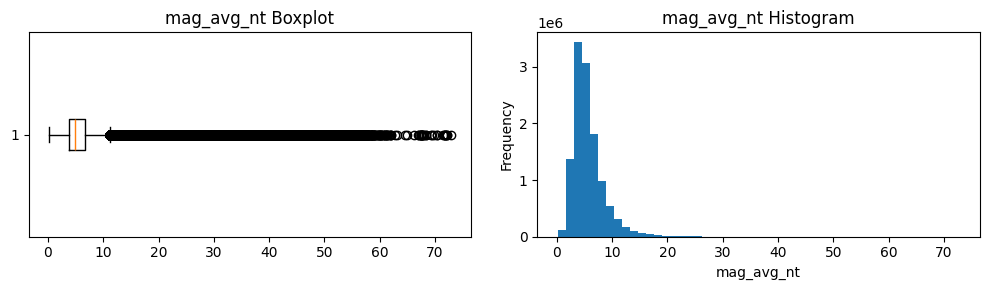

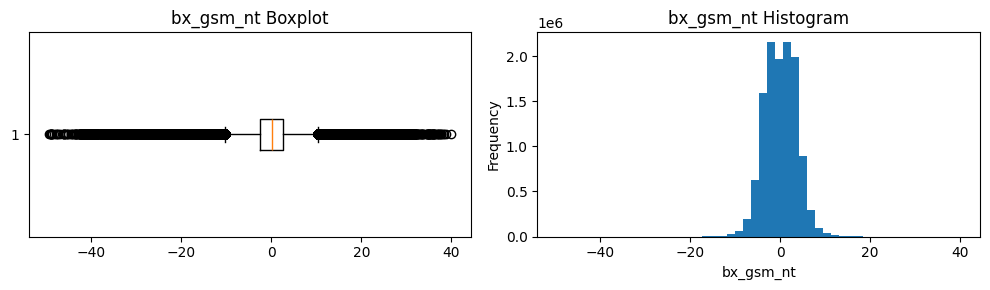

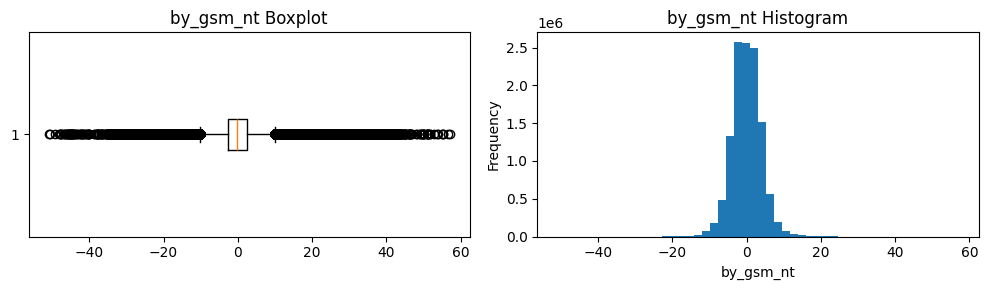

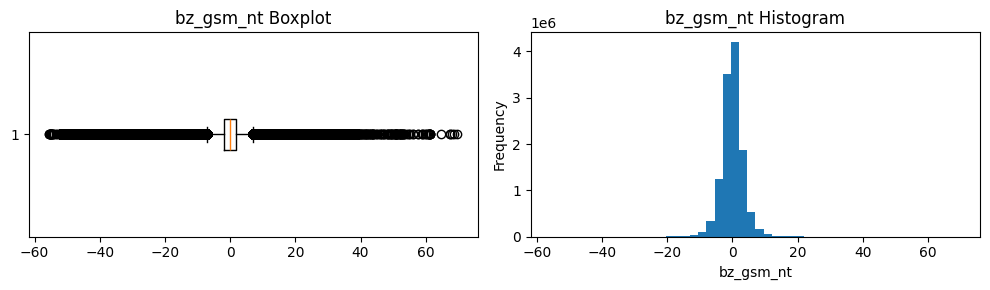

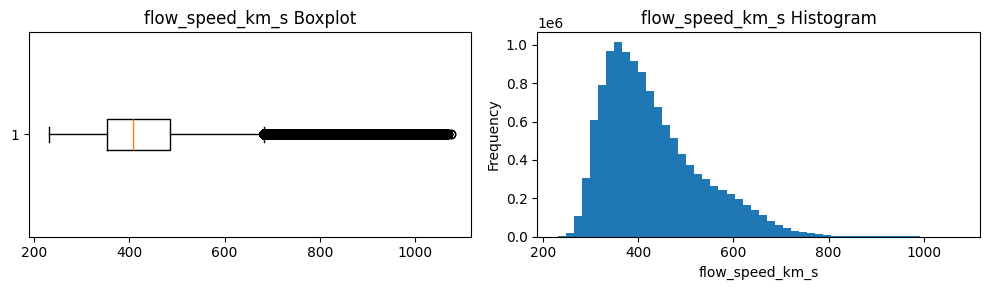

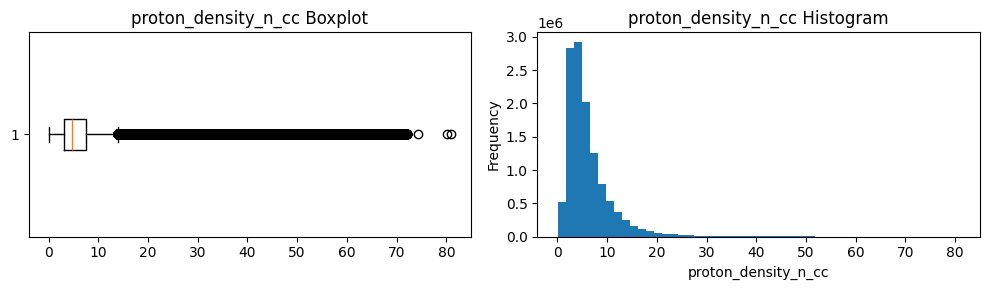

In [27]:
for col in FEATURE_VARS:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    # Boxplot
    axes[0].boxplot(train_df[col], vert=False)
    axes[0].set_title(f"{col} Boxplot")

    # Histogram
    axes[1].hist(train_df[col], bins=50)
    axes[1].set_title(f"{col} Histogram")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a18bf7d-431c-4909-af8a-a54a62228a78' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>